
# **ViT vs ResNet on Chest X‑rays — Paper‑Aligned (ICLR’22 SAM) End‑to‑End**

**Goal.** Reproduce the core comparison from “When Vision Transformers Outperform ResNets without Pre‑training or Strong Data Augmentations” (ICLR 2022) on chest X‑rays, with a screening‑oriented evaluation (recall‑first thresholding).

We run scratch‑training only (to match the paper’s headline claim), with and without SAM:

- ResNet‑18 (scratch) and ResNet‑18 (scratch + SAM)
- ViT‑Small (scratch) and ViT‑Small (scratch + SAM)

**Why scratch?** The paper’s main result is that, with the right optimizer & schedule (Inception‑style preprocessing, cosine LR + warmup, and SAM), ViTs trained from scratch can surpass ResNets of similar size without pre‑training or strong augmentations.

> **Screening metric policy**: we select a probability threshold on the validation set to meet a target recall (e.g., 0.95). We then report test metrics at that threshold. We also report the default 0.5 threshold for reference.


In [10]:

# --- Environment & Paths ---
from dataclasses import dataclass
from pathlib import Path
import os, time, math, random, json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision as tv
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    average_precision_score
)
from sklearn.model_selection import StratifiedShuffleSplit

# Device (MPS on macOS if available; safe on CPU)
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

# Paths (edit DATASET_DIR if your path differs)
# Paths (assuming this notebook lives in notebooks/)
REPO_ROOT   = Path.cwd().parent
DATASET_DIR = REPO_ROOT / "Data" / "chest_xray"
WEIGHTS_DIR = Path.cwd() / "weights"
WEIGHTS_DIR.mkdir(exist_ok=True, parents=True)
print("Dataset dir:", DATASET_DIR.resolve())
print("Weights dir:", WEIGHTS_DIR.resolve())

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

@dataclass
class CFG:
    image_size: int = 224
    in_channels: int = 3
    batch_size: int = 32
    num_workers: int = 2
    # schedule (paper-aligned): cosine + warmup
    warmup_epochs: int = 2
    epochs_resnet: int = 40
    epochs_vit: int = 60
    base_lr_resnet: float = 0.1
    base_lr_vit: float = 3e-4
    weight_decay_resnet: float = 1e-3
    weight_decay_vit: float = 0.3
    label_smoothing: float = 0.0
    target_recall: float = 0.95
    monitor: str = "va_auroc"
    patience: int = 10
    # SAM strengths
    sam_rho_resnet: float = 0.05
    sam_rho_vit: float = 0.2
    # stratified re-split (optional)
    use_stratified_val: bool = True
    stratified_val_size: float = 0.15

cfg = CFG()
print(cfg)
print("Dataset dir:", DATASET_DIR.resolve())


Device: mps
Dataset dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/Data/chest_xray
Weights dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/notebooks/weights
CFG(image_size=224, in_channels=3, batch_size=32, num_workers=2, warmup_epochs=2, epochs_resnet=40, epochs_vit=60, base_lr_resnet=0.1, base_lr_vit=0.0003, weight_decay_resnet=0.001, weight_decay_vit=0.3, label_smoothing=0.0, target_recall=0.95, monitor='va_auroc', patience=10, sam_rho_resnet=0.05, sam_rho_vit=0.2, use_stratified_val=True, stratified_val_size=0.15)
Dataset dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/Data/chest_xray


In [17]:
from torch.utils.data import Dataset
from PIL import Image

class StratifiedImageDataset(Dataset):
    """Top-level picklable dataset used when cfg.use_stratified_val=True."""
    def __init__(self, paths, targets, transform, classes):
        self.paths = list(paths)
        self.targets = list(targets)
        self.transform = transform
        self.samples = list(zip(self.paths, self.targets))
        self.classes = list(classes)
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        p, y = self.paths[i], self.targets[i]
        img = Image.open(p).convert("RGB")  # force 3-channel
        if self.transform is not None:
            img = self.transform(img)
        return img, y


In [ ]:
if cfg.use_stratified_val:
    # Merge official train + val, then stratify
    all_imgs = list(ds_train_raw.imgs) + list(ds_val_raw.imgs)
    all_targets = [y for (_, y) in all_imgs]
    all_paths   = [p for (p, _) in all_imgs]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=cfg.stratified_val_size, random_state=42)
    idx_train, idx_val = next(sss.split(np.zeros(len(all_targets)), all_targets))

    train_paths = [all_paths[i] for i in idx_train]
    train_tgts  = [all_targets[i] for i in idx_train]
    val_paths   = [all_paths[i] for i in idx_val]
    val_tgts    = [all_targets[i] for i in idx_val]

    # build top-level, picklable datasets
    train_ds = StratifiedImageDataset(train_paths, train_tgts, train_tf, classes)
    val_ds   = StratifiedImageDataset(val_paths,  val_tgts,  eval_tf,   classes)
else:
    train_ds, val_ds = ds_train_raw, ds_val_raw


In [18]:

# --- Datasets & Inception-style preprocessing ---
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # ensure 3‑ch tensors
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256),
    transforms.CenterCrop(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

assert (DATASET_DIR / "train").exists(), f"DATASET_DIR not found: {DATASET_DIR}"
ds_train_raw = tv.datasets.ImageFolder(DATASET_DIR / "train", transform=train_tf)
ds_val_raw   = tv.datasets.ImageFolder(DATASET_DIR / "val",   transform=eval_tf)
ds_test      = tv.datasets.ImageFolder(DATASET_DIR / "test",  transform=eval_tf)
classes = ds_train_raw.classes
print("Classes:", classes)

if cfg.use_stratified_val:
    all_imgs = list(ds_train_raw.imgs) + list(ds_val_raw.imgs)
    all_targets = [y for (_,y) in all_imgs]
    all_paths = [p for (p,_) in all_imgs]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=cfg.stratified_val_size, random_state=42)
    idx_train, idx_val = next(sss.split(np.zeros(len(all_targets)), all_targets))

    class _DS(torch.utils.data.Dataset):
        def __init__(self, paths, targets, transform):
            self.paths, self.targets, self.transform = paths, targets, transform
            self.samples = list(zip(paths, targets))
            self.classes = classes
            self.class_to_idx = {c:i for i,c in enumerate(classes)}
        def __len__(self): return len(self.paths)
        def __getitem__(self, i):
            p, y = self.paths[i], self.targets[i]
            im = tv.io.read_image(p).float()/255.0
            im = transforms.functional.resize(im, [max(im.shape[1], cfg.image_size), max(im.shape[2], cfg.image_size)])
            im = transforms.functional.center_crop(im, [cfg.image_size, cfg.image_size])
            im = transforms.functional.to_pil_image(im)
            im = self.transform(im)
            return im, y

    train_ds = _DS([all_paths[i] for i in idx_train], [all_targets[i] for i in idx_train], train_tf)
    val_ds   = _DS([all_paths[i] for i in idx_val],   [all_targets[i] for i in idx_val],   eval_tf)
else:
    train_ds, val_ds = ds_train_raw, ds_val_raw

train_counts = np.bincount([y for _,y in (train_ds.samples if hasattr(train_ds,'samples') else train_ds)])
print("Lens:", len(train_ds), len(val_ds), len(ds_test))
print("Train counts:", train_counts)

# macOS/MPS: often better with 0 or 1 worker
cfg.num_workers = 0

pin = (DEVICE.type == "cuda")  # False on MPS/CPU
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=pin)
test_loader  = DataLoader(ds_test,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=pin)

Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4447 785 624
Train counts: [1147 3300]


In [19]:
from torch.utils.data import Dataset
from PIL import Image

class StratifiedImageDataset(Dataset):
    """Top-level picklable dataset used when cfg.use_stratified_val=True."""
    def __init__(self, paths, targets, transform, classes):
        self.paths = list(paths)
        self.targets = list(targets)
        self.transform = transform
        self.samples = list(zip(self.paths, self.targets))
        self.classes = list(classes)
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        p, y = self.paths[i], self.targets[i]
        img = Image.open(p).convert("RGB")  # force 3-channel
        if self.transform is not None:
            img = self.transform(img)
        return img, y


In [20]:

# --- SAM optimizer (robust kwargs) ---
import inspect
from torch.optim import Optimizer

class SAM(Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        sig = inspect.signature(base_optimizer.__init__)
        valid = {k:v for k,v in kwargs.items() if k in sig.parameters}
        defaults = dict(rho=rho, **valid)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **valid)
        self.rho = rho

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = self.rho / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                p.add_(p.grad * scale)
        if zero_grad:
            self.zero_grad(set_to_none=True)

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad(set_to_none=True)

    def step(self, closure=None):
        if closure is None:
            raise RuntimeError("SAM requires a closure")
        loss = closure()
        self.first_step(zero_grad=True)
        closure()
        self.second_step(zero_grad=True)
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def _grad_norm(self):
        device = self.param_groups[0]["params"][0].device
        norms = []
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                norms.append(torch.norm(p.grad.detach(), p=2).to(device))
        if not norms:
            return torch.tensor(0., device=device)
        return torch.norm(torch.stack(norms), p=2)

# --- Cosine w/ linear warmup ---
class WarmupCosineLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs, total_epochs, last_epoch=-1):
        self.warmup_epochs = max(1, warmup_epochs)
        self.total_epochs  = max(self.warmup_epochs+1, total_epochs)
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        e = self.last_epoch + 1
        lrs = []
        for base_lr in self.base_lrs:
            if e <= self.warmup_epochs:
                lr = base_lr * e / self.warmup_epochs
            else:
                t = (e - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
                lr = 0.5 * base_lr * (1 + math.cos(math.pi * t))
            lrs.append(lr)
        return lrs


In [21]:

# --- Models ---
def build_resnet18_scratch(num_classes=2):
    m = tv.models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=384):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)
    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x

class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        x = self.fc1(x); x = self.act(x); x = self.drop(x)
        x = self.fc2(x); x = self.drop(x); 
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=6, qkv_bias=True, attn_drop=0.0, proj_drop=0.1):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim*3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        q, k, v = qkv.permute(2,0,3,1,4)
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1,2).reshape(B, N, C)
        x = self.proj(x); x = self.proj_drop(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp  = MLP(dim, mlp_ratio=mlp_ratio, drop=drop)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformerSmall(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=2,
                 embed_dim=384, depth=8, num_heads=6, mlp_ratio=4.0, drop_rate=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1+self.patch_embed.num_patches, embed_dim))
        self.pos_drop = nn.Dropout(drop_rate)
        self.blocks = nn.ModuleList([Block(embed_dim, num_heads, mlp_ratio, drop=drop_rate) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x[:,0]
        return self.head(x)

def build_vit_small_scratch(num_classes=2):
    return VisionTransformerSmall(
        img_size=224, patch_size=16, in_chans=3,
        num_classes=num_classes, embed_dim=384, depth=8, num_heads=6,
        mlp_ratio=4.0, drop_rate=0.1
    )


In [22]:

# --- Utilities: plots & metrics ---
def plot_curve(tr, va, title):
    xs = range(1, len(tr)+1)
    plt.figure(figsize=(6,3)); plt.plot(xs, tr, label="train"); plt.plot(xs, va, label="val")
    plt.title(title); plt.xlabel("epoch"); plt.legend(); plt.show()

def plot_two_series(a, a_name, b, b_name, title):
    xs = range(1, len(a)+1)
    plt.figure(figsize=(6,3)); plt.plot(xs, a, label=a_name); plt.plot(xs, b, label=b_name)
    plt.title(title); plt.xlabel("epoch"); plt.legend(); plt.show()

def diag_plots(title, probs, y_true, thr, auroc=np.nan):
    y_prob = probs[:,1]
    y_hat = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(4,3))
    plt.imshow(cm, cmap="viridis"); plt.title(f"{title} — Confusion (thr={thr:.3f})")
    plt.xticks([0,1], classes); plt.yticks([0,1], classes); plt.colorbar(); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5,3.5)); plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
    plt.title(f"{title} — ROC (AUROC={auroc:.4f})"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.show()

    pr_p, pr_r, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(5,3.5)); plt.plot(pr_r, pr_p)
    plt.title(f"{title} — PR (AP={ap:.4f})"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.show()

def make_criterion(class_weights=None, label_smoothing=0.0):
    w = class_weights.to(DEVICE) if class_weights is not None else None
    return nn.CrossEntropyLoss(weight=w, label_smoothing=label_smoothing)

def choose_threshold_by_min_recall(y_true, y_prob, target_recall=0.95):
    uniq = np.unique(y_prob)
    cand = np.linspace(0.0, 1.0, num=501) if len(uniq) > 1000 else np.unique(np.concatenate([[0.0,1.0], uniq]))
    for t in np.sort(cand):
        yh = (y_prob >= t).astype(int)
        r = recall_score(y_true, yh, zero_division=0)
        if r >= target_recall:
            p = precision_score(y_true, yh, zero_division=0)
            f1 = f1_score(y_true, yh, zero_division=0)
            return float(t), float(r), float(p), float(f1)
    yh = (y_prob >= 0.5).astype(int)
    return 0.5, recall_score(y_true, yh, zero_division=0), precision_score(y_true, yh, zero_division=0), f1_score(y_true, yh, zero_division=0)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval(); probs=[]; targs=[]; logits_all=[]
    for xb, yb in loader:
        xb = xb.to(device)
        out = model(xb); logits_all.append(out.detach().cpu().numpy())
        p = F.softmax(out, dim=1)[:,1].detach().cpu().numpy()
        probs.append(p); targs.append(yb.numpy())
    probs = np.concatenate(probs); targs = np.concatenate(targs); logits = np.concatenate(logits_all)
    return {'targets': targs, 'probs': np.stack([1-probs, probs], 1), 'logits': logits,
            'auroc': roc_auc_score(targs, probs)}

def summarize_at_threshold(y_true, y_prob, thr):
    yhat = (y_prob >= thr).astype(int)
    return dict(
        acc = accuracy_score(y_true, yhat),
        precision = precision_score(y_true, yhat, zero_division=0),
        recall = recall_score(y_true, yhat, zero_division=0),
        f1 = f1_score(y_true, yhat, zero_division=0),
        auroc = roc_auc_score(y_true, y_prob),
        thr = float(thr)
    )


In [24]:

# --- Training loop with optional SAM & cosine warmup ---
def train_model(model, train_loader, val_loader, device, epochs, base_lr, weight_decay,
                class_weights=None, monitor='va_auroc', patience=8,
                use_sam=False, sam_rho=0.05, tag='model'):
    model = model.to(device)
    crit = make_criterion(class_weights, label_smoothing=0.0)

    # choose optimizer
    if isinstance(model, tv.models.ResNet):
        base_opt = torch.optim.SGD
        opt_kwargs = dict(lr=base_lr, momentum=0.9, weight_decay=weight_decay, nesterov=True)
    else:
        base_opt = torch.optim.AdamW
        opt_kwargs = dict(lr=base_lr, weight_decay=weight_decay)

    if use_sam:
        opt = SAM(model.parameters(), base_opt, rho=sam_rho, **opt_kwargs)
    else:
        opt = base_opt(model.parameters(), **opt_kwargs)

    sched = WarmupCosineLR(opt.base_optimizer if use_sam else opt,
                           warmup_epochs=2, total_epochs=epochs)

    best = None; best_metric = -1e9; no_improve=0
    hist = {'tr_loss':[], 'va_loss':[], 'va_acc':[], 'va_f1':[], 'va_auroc':[]}
    t0 = time.time()

    for ep in range(1, epochs+1):
        model.train(); tr_losses=[]
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if use_sam:
                def closure():
                    opt.zero_grad(set_to_none=True)
                    out = model(xb); loss = crit(out, yb)
                    loss.backward()
                    return loss
                loss = opt.step(closure)
            else:
                out = model(xb); loss = crit(out, yb)
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            tr_losses.append(float(loss.item()))
        sched.step()

        # validation
        model.eval(); va_losses=[]; preds=[]; targs=[]
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb); loss = crit(out, yb)
                va_losses.append(float(loss.item()))
                probs = F.softmax(out, dim=1)[:,1].detach().cpu().numpy()
                preds.extend(probs); targs.extend(yb.cpu().numpy())
        targs = np.array(targs); preds = np.array(preds)
        yhat = (preds >= 0.5).astype(int)
        va_acc = accuracy_score(targs, yhat)
        va_f1  = f1_score(targs, yhat, zero_division=0)
        va_auroc = roc_auc_score(targs, preds)

        hist['tr_loss'].append(np.mean(tr_losses))
        hist['va_loss'].append(np.mean(va_losses))
        hist['va_acc'].append(va_acc)
        hist['va_f1'].append(va_f1)
        hist['va_auroc'].append(va_auroc)

        metric = va_auroc if monitor=='va_auroc' else va_f1
        improved = metric > best_metric
        if improved:
            best_metric = metric; best = {k:v.cpu() for k,v in model.state_dict().items()}; no_improve=0
        else:
            no_improve += 1

        print(f"[{tag}] epoch {ep:02d}/{epochs:02d}  tr_loss={np.mean(tr_losses):.4f}  "
              f"val_loss={np.mean(va_losses):.4f}  val_acc={va_acc:.4f}  val_f1={va_f1:.4f}  "
              f"val_auroc={va_auroc:.4f}  (no_improve={no_improve})")
        if no_improve >= patience:
            print(f"[{tag}] early stopping at epoch {ep}."); break

    if best is not None:
        model.load_state_dict(best)
    return model, hist, time.time()-t0


## Experiments (scratch; paper‑aligned)

In [25]:

# Helper for class weights
arr = np.array(train_counts, dtype=float)
cw = torch.tensor(arr.sum() / (len(arr) * (arr + 1e-9)), dtype=torch.float32)

results_registry = {}

def run_and_log(model, tag, epochs, base_lr, weight_decay, use_sam, sam_rho):
    model, hist, tsec = train_model(
        model, train_loader, val_loader, DEVICE,
        epochs=epochs, base_lr=base_lr, weight_decay=weight_decay,
        class_weights=cw, monitor="va_auroc", patience=10,
        use_sam=use_sam, sam_rho=sam_rho, tag=tag
    )
    plot_curve(hist["tr_loss"], hist["va_loss"], f"{tag} — Loss")
    plot_two_series(hist["va_acc"], "Val Acc", hist["va_f1"], "Val F1", f"{tag} — Val Acc/F1")

    val_eval = evaluate(model, val_loader, DEVICE)
    thr, rec, prec, f1v = choose_threshold_by_min_recall(val_eval["targets"], val_eval["probs"][:,1], 0.95)
    print(f"[{tag}] chosen thr on VAL: {thr:.3f} (VAL recall={rec:.3f}, precision={prec:.3f})")

    test_eval = evaluate(model, test_loader, DEVICE)
    y_test = test_eval["targets"]; p1 = test_eval["probs"][:,1]
    summary_05   = summarize_at_threshold(y_test, p1, 0.5)
    summary_reca = summarize_at_threshold(y_test, p1, thr)
    print(f"[{tag} @0.5]", {k: round(v,4) for k,v in summary_05.items()})
    print(f"[{tag} @Rec]", {k: round(v,4) for k,v in summary_reca.items()})
    diag_plots(tag, test_eval["probs"], y_test, thr, auroc=test_eval.get("auroc"))

    res = {
        "summary@0.5": summary_05,
        "summary@recall": summary_reca,
        "threshold": float(thr),
        "time_sec": float(tsec),
        "params": int(sum(p.numel() for p in model.parameters())),
    }
    results_registry[tag] = res
    globals()[tag.replace("-","_").lower() + "_results"] = res
    return res


[ResNet18-scratch] epoch 01/40  tr_loss=0.8900  val_loss=1.7868  val_acc=0.3350  val_f1=0.1920  val_auroc=0.5732  (no_improve=0)
[ResNet18-scratch] epoch 02/40  tr_loss=0.5623  val_loss=1.5228  val_acc=0.3236  val_f1=0.1664  val_auroc=0.5530  (no_improve=1)
[ResNet18-scratch] epoch 03/40  tr_loss=0.4455  val_loss=2.8988  val_acc=0.7427  val_f1=0.8523  val_auroc=0.4489  (no_improve=2)
[ResNet18-scratch] epoch 04/40  tr_loss=0.4401  val_loss=2.4788  val_acc=0.7427  val_f1=0.8523  val_auroc=0.5662  (no_improve=3)
[ResNet18-scratch] epoch 05/40  tr_loss=0.4314  val_loss=0.6449  val_acc=0.6255  val_f1=0.7151  val_auroc=0.6850  (no_improve=0)
[ResNet18-scratch] epoch 06/40  tr_loss=0.4078  val_loss=0.9306  val_acc=0.3758  val_f1=0.2773  val_auroc=0.8360  (no_improve=0)
[ResNet18-scratch] epoch 07/40  tr_loss=0.4126  val_loss=2.6907  val_acc=0.7427  val_f1=0.8523  val_auroc=0.6180  (no_improve=1)
[ResNet18-scratch] epoch 08/40  tr_loss=0.4220  val_loss=1.7307  val_acc=0.7427  val_f1=0.8523  v

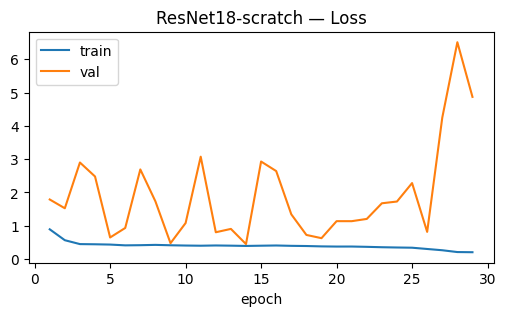

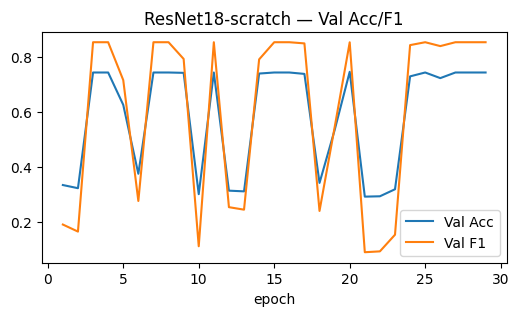

[ResNet18-scratch] chosen thr on VAL: 0.000 (VAL recall=1.000, precision=0.743)
[ResNet18-scratch @0.5] {'acc': 0.5465, 'precision': 0.8166, 'recall': 0.3538, 'f1': 0.4937, 'auroc': 0.7036, 'thr': 0.5}
[ResNet18-scratch @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.7036, 'thr': 0.0}


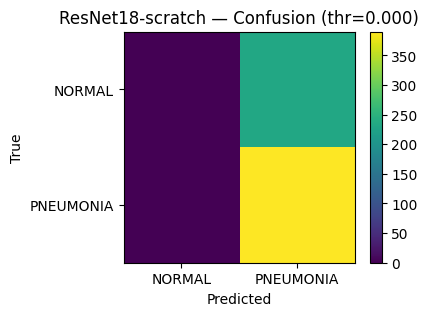

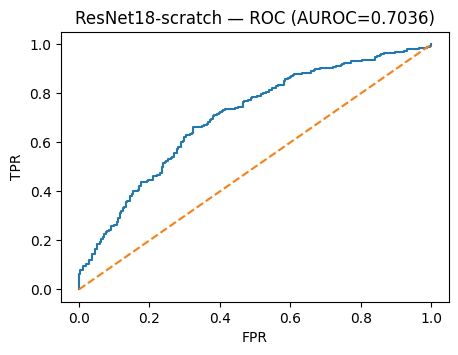

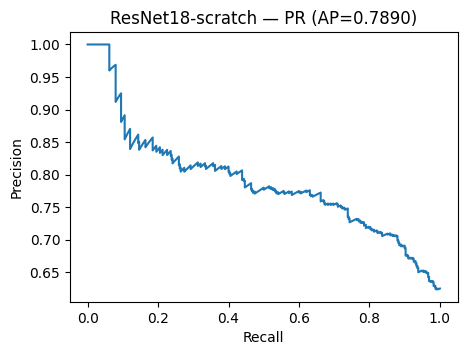

In [26]:

# A) ResNet‑18 (scratch)
resnet18_scratch = build_resnet18_scratch(num_classes=2).to(DEVICE)
resnet18_scratch_results = run_and_log(
    resnet18_scratch, tag="ResNet18-scratch",
    epochs=40, base_lr=0.1, weight_decay=1e-3,
    use_sam=False, sam_rho=0.05
)


[ResNet18-scratch+SAM] epoch 01/40  tr_loss=0.9112  val_loss=0.7521  val_acc=0.3643  val_f1=0.2758  val_auroc=0.4975  (no_improve=0)
[ResNet18-scratch+SAM] epoch 02/40  tr_loss=0.5624  val_loss=0.6895  val_acc=0.3962  val_f1=0.3542  val_auroc=0.5899  (no_improve=0)
[ResNet18-scratch+SAM] epoch 03/40  tr_loss=0.4567  val_loss=1.3420  val_acc=0.3096  val_f1=0.1342  val_auroc=0.6306  (no_improve=0)
[ResNet18-scratch+SAM] epoch 04/40  tr_loss=0.4567  val_loss=0.3996  val_acc=0.8293  val_f1=0.8771  val_auroc=0.8767  (no_improve=0)
[ResNet18-scratch+SAM] epoch 05/40  tr_loss=0.4350  val_loss=2.7956  val_acc=0.7452  val_f1=0.8534  val_auroc=0.7709  (no_improve=1)
[ResNet18-scratch+SAM] epoch 06/40  tr_loss=0.4305  val_loss=0.9107  val_acc=0.3197  val_f1=0.1577  val_auroc=0.4752  (no_improve=2)
[ResNet18-scratch+SAM] epoch 07/40  tr_loss=0.4184  val_loss=2.9563  val_acc=0.7414  val_f1=0.8515  val_auroc=0.7536  (no_improve=3)
[ResNet18-scratch+SAM] epoch 08/40  tr_loss=0.4307  val_loss=1.0550  

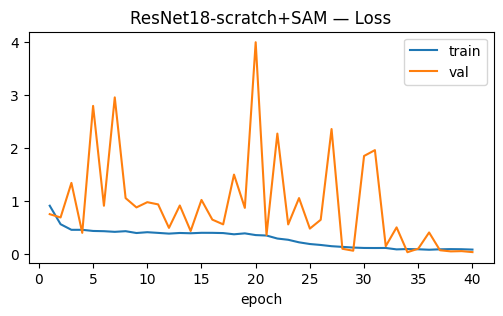

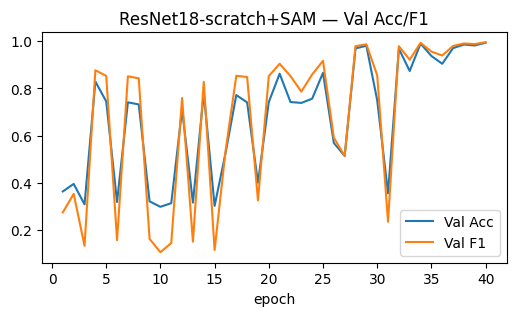

[ResNet18-scratch+SAM] chosen thr on VAL: 0.000 (VAL recall=1.000, precision=0.743)
[ResNet18-scratch+SAM @0.5] {'acc': 0.6266, 'precision': 0.6298, 'recall': 0.9769, 'f1': 0.7658, 'auroc': 0.5386, 'thr': 0.5}
[ResNet18-scratch+SAM @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.5386, 'thr': 0.0}


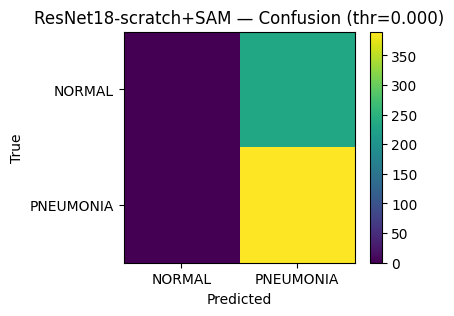

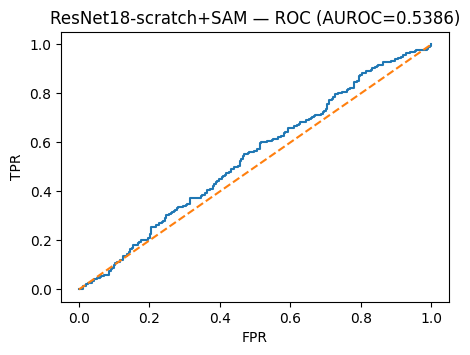

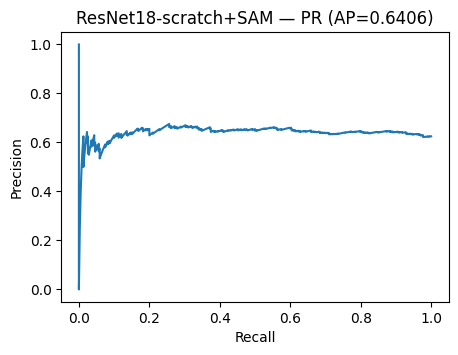

In [27]:

# B) ResNet‑18 (scratch + SAM)
resnet18_scratch_sam = build_resnet18_scratch(num_classes=2).to(DEVICE)
resnet18_scratch_sam_results = run_and_log(
    resnet18_scratch_sam, tag="ResNet18-scratch+SAM",
    epochs=40, base_lr=0.1, weight_decay=1e-3,
    use_sam=True, sam_rho=0.05
)


[ViT-small-scratch] epoch 01/60  tr_loss=0.7317  val_loss=0.6665  val_acc=0.4955  val_f1=0.5570  val_auroc=0.5839  (no_improve=0)
[ViT-small-scratch] epoch 02/60  tr_loss=0.7041  val_loss=0.7492  val_acc=0.7427  val_f1=0.8523  val_auroc=0.5942  (no_improve=0)
[ViT-small-scratch] epoch 03/60  tr_loss=0.6808  val_loss=0.6498  val_acc=0.5732  val_f1=0.6440  val_auroc=0.6587  (no_improve=0)
[ViT-small-scratch] epoch 04/60  tr_loss=0.6711  val_loss=0.6369  val_acc=0.7159  val_f1=0.8115  val_auroc=0.7068  (no_improve=0)
[ViT-small-scratch] epoch 05/60  tr_loss=0.6524  val_loss=0.5920  val_acc=0.6892  val_f1=0.7608  val_auroc=0.7542  (no_improve=0)
[ViT-small-scratch] epoch 06/60  tr_loss=0.6349  val_loss=0.5975  val_acc=0.7236  val_f1=0.7970  val_auroc=0.7642  (no_improve=0)
[ViT-small-scratch] epoch 07/60  tr_loss=0.6262  val_loss=0.5966  val_acc=0.7631  val_f1=0.8391  val_auroc=0.7728  (no_improve=0)
[ViT-small-scratch] epoch 08/60  tr_loss=0.6189  val_loss=0.5880  val_acc=0.6841  val_f1=0

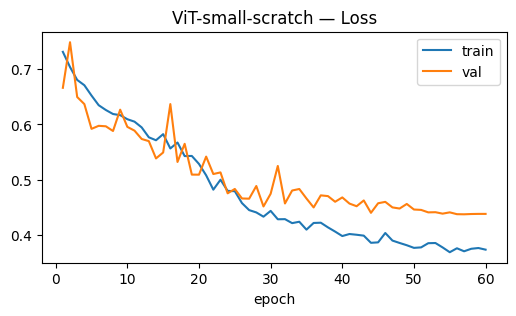

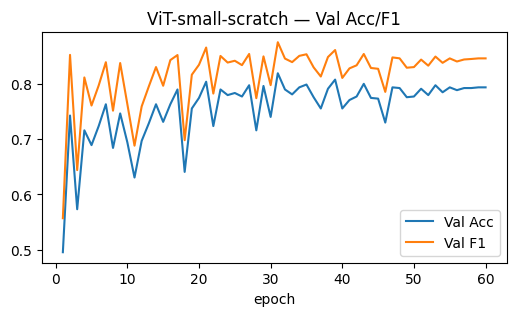

[ViT-small-scratch] chosen thr on VAL: 0.000 (VAL recall=1.000, precision=0.743)
[ViT-small-scratch @0.5] {'acc': 0.4712, 'precision': 0.5607, 'recall': 0.7103, 'f1': 0.6267, 'auroc': 0.326, 'thr': 0.5}
[ViT-small-scratch @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.326, 'thr': 0.0}


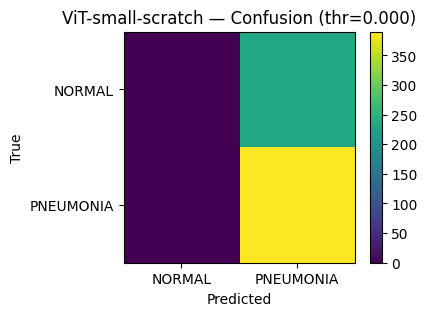

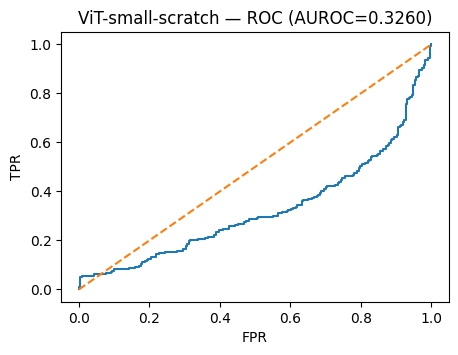

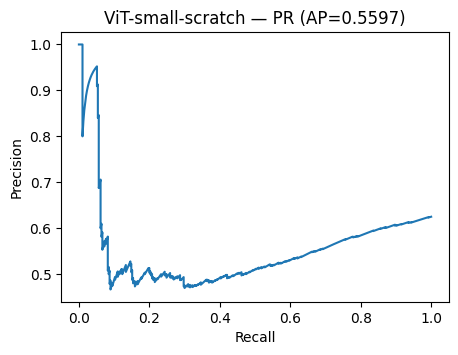

In [28]:

# C) ViT‑Small (scratch)
vit_scratch = build_vit_small_scratch(num_classes=2).to(DEVICE)
vit_scratch_results = run_and_log(
    vit_scratch, tag="ViT-small-scratch",
    epochs=60, base_lr=3e-4, weight_decay=0.3,
    use_sam=False, sam_rho=0.2
)


[ViT-small-scratch+SAM] epoch 01/60  tr_loss=0.7512  val_loss=0.7469  val_acc=0.3962  val_f1=0.3435  val_auroc=0.5689  (no_improve=0)
[ViT-small-scratch+SAM] epoch 02/60  tr_loss=0.7310  val_loss=0.6748  val_acc=0.7427  val_f1=0.8523  val_auroc=0.5798  (no_improve=0)
[ViT-small-scratch+SAM] epoch 03/60  tr_loss=0.6994  val_loss=0.6759  val_acc=0.3796  val_f1=0.3053  val_auroc=0.5744  (no_improve=1)
[ViT-small-scratch+SAM] epoch 04/60  tr_loss=0.6865  val_loss=0.6714  val_acc=0.3809  val_f1=0.3077  val_auroc=0.5749  (no_improve=2)
[ViT-small-scratch+SAM] epoch 05/60  tr_loss=0.6898  val_loss=0.6781  val_acc=0.3643  val_f1=0.2694  val_auroc=0.5778  (no_improve=3)
[ViT-small-scratch+SAM] epoch 06/60  tr_loss=0.6806  val_loss=0.6718  val_acc=0.3745  val_f1=0.2894  val_auroc=0.5751  (no_improve=4)
[ViT-small-scratch+SAM] epoch 07/60  tr_loss=0.6805  val_loss=0.6741  val_acc=0.3783  val_f1=0.2989  val_auroc=0.5776  (no_improve=5)
[ViT-small-scratch+SAM] epoch 08/60  tr_loss=0.6805  val_loss=

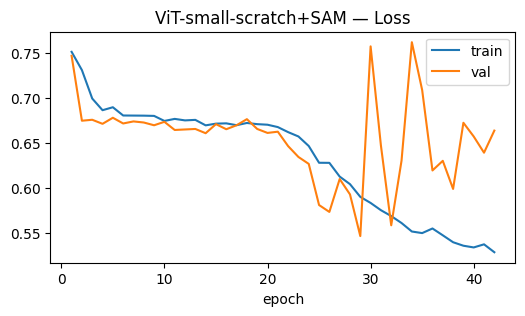

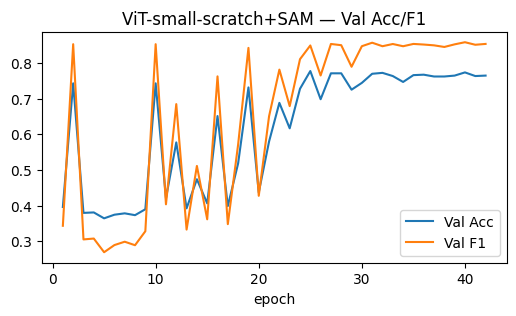

[ViT-small-scratch+SAM] chosen thr on VAL: 0.000 (VAL recall=1.000, precision=0.743)
[ViT-small-scratch+SAM @0.5] {'acc': 0.7484, 'precision': 0.8675, 'recall': 0.7051, 'f1': 0.7779, 'auroc': 0.8174, 'thr': 0.5}
[ViT-small-scratch+SAM @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.8174, 'thr': 0.0}


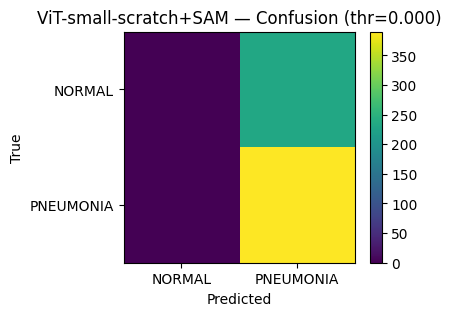

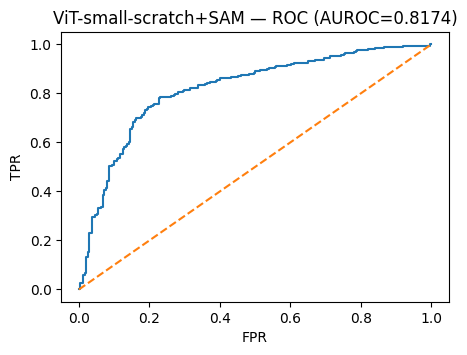

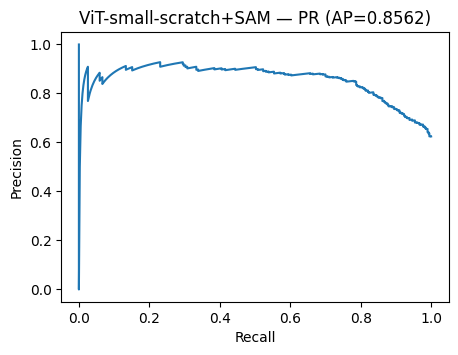

In [29]:

# D) ViT‑Small (scratch + SAM)
vit_scratch_sam = build_vit_small_scratch(num_classes=2).to(DEVICE)
vit_scratch_sam_results = run_and_log(
    vit_scratch_sam, tag="ViT-small-scratch+SAM",
    epochs=60, base_lr=3e-4, weight_decay=0.3,
    use_sam=True, sam_rho=0.2
)


In [34]:
# %% [code] {"id":"compare"}
rows = []
def add_row(name, res):
    if res is None: return
    r = res["summary@recall"]
    rows.append({
        "Model": name,
        "Params (M)": round(res["params"]/1e6, 2),
        "Time (min)": round(res["time_sec"]/60.0, 2),
        "Acc": round(r["acc"], 4),
        "Prec": round(r["precision"], 4),
        "Recall": round(r["recall"], 4),
        "F1": round(r["f1"], 4),
        "AUROC": round(r["auroc"], 4),
        "Thr": round(res["threshold"], 3)
    })

add_row("CNN - resnet18 (scratch)", resnet18_scratch_results)
add_row("CNN - resnet18 (scratch) + SAM", resnet18_scratch_sam_results)
add_row("ViT (scratch+SAM)", vit_scratch_sam_results)
add_row("vit_scratch", vit_scratch_results)

df = pd.DataFrame(rows)
df

,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,CNN - resnet18 (scratch),11.18,30.10,0.625,0.625,1.0,0.7692,0.7036,0.0
1,CNN - resnet18 (scratch) + SAM,11.18,56.40,0.625,0.625,1.0,0.7692,0.5386,0.0
2,ViT (scratch+SAM),14.57,387.32,0.625,0.625,1.0,0.7692,0.8174,0.0
3,vit_scratch,14.57,90.09,0.625,0.625,1.0,0.7692,0.3260,0.0


In [38]:
# === RESULTS NORMALIZER & FINAL TABLE (robust) ===
import math, numpy as np, pandas as pd

def _looks_like_summary(d):
    if not isinstance(d, dict): return False
    k = {x.lower() for x in d.keys()}
    return {"acc","precision","recall","f1"}.issubset(k)

def _extract_summary(res):
    if not isinstance(res, dict): return None
    for k in ("summary@recall","summary@0.5","summary","metrics"):
        v = res.get(k)
        if isinstance(v, dict) and _looks_like_summary(v):
            thr = res.get("threshold", v.get("thr", 0.5))
            return v, thr, res.get("time_sec", res.get("train_time_sec")), res.get("params", res.get("n_params"))
    if _looks_like_summary(res):
        return res, res.get("thr",0.5), res.get("time_sec"), res.get("params")
    return None

def _row(name, res):
    ext = _extract_summary(res)
    if not ext: return None
    summ, thr, time_sec, params = ext
    return {
        "Model": name,
        "Params (M)": round(params/1e6, 2) if isinstance(params,(int,float,np.number)) else None,
        "Time (min)": round(time_sec/60, 2) if isinstance(time_sec,(int,float,np.number)) else None,
        "Acc": round(float(summ["acc"]),4),
        "Prec": round(float(summ["precision"]),4),
        "Recall": round(float(summ["recall"]),4),
        "F1": round(float(summ["f1"]),4),
        "AUROC": round(float(summ.get("auroc", float("nan"))),4),
        "Thr": round(float(thr),3),
    }

# Expect these names in THIS notebook:
candidates = {
    "ResNet18 (scratch)"         : globals().get("resnet18_scratch_results"),
    "ResNet18 (scratch + SAM)"   : globals().get("resnet18_scratch_sam_results"),
    "ViT (scratch)"              : globals().get("vit_scratch_results"),
    "ViT (scratch + SAM)"        : globals().get("vit_scratch_sam_results"),
}

rows = [r for name,res in candidates.items() if (r:=_row(name,res))]
if not rows:
    print("No populated result dicts found. Run the experiment cells first.")
else:
    df = pd.DataFrame(rows).dropna(how="all", axis=1)
    # Screening emphasis: sort by F1, tie-break by AUROC
    df = df.sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
    try:
        from ace_tools import display_dataframe_to_user
        display_dataframe_to_user("Final comparison", df)
    except Exception:
        pass
    df
